# Part 3 verdict at a glance — 9-level retrain (`qn8620_s0_q9`)

Graphical summary of the 2026-08-27 validation run. Everything here is recomputed
from **cached artifacts** (claims feathers, eval-band feathers, the 50r1 CSV) — no
model loads, runs in ~1 min. The deep-dive notebooks stay the source of truth:
`cqr_per_level_validity` (marginal + monthly spread + gated bands),
`cdf_rung_coverage` (19-rung + regime views), `card_claim_reliability` (claims).

| Gate | Result | Verdict |
|---|---|---|
| 3.1 marginal per-level (±0.35 pp) | worst +0.44 pp (tmin q75); all other rungs within | ✅ pass |
| 3.2 rung coverage vs 7-level | precip wet 55–85 improved +2.0…+4.8 → +0.1…+1.8 pp; tmax/wind unchanged; **tmin cross-month worst err 2.1 → 3.8 pp** | ⚠️ watch tmin |
| 3.3 tier-conditional bands | ALL-rows ≤2.4 pp; extreme-tier interior over-covers +10/+12 pp (selection effect) | as predicted |
| 3.4 tier claim gaps vs 7-level baseline | extreme −9.2/−9.9/−14.8/−12.1 pp (was −8.2/−8.6/−16.0/−13.3); ECE all ≤3 pp | unchanged ⇒ per-tier p-remap still the fix |
| 50r1 pinned-cycle addendum | cycle-attributable gaps ≤2.5 pp vs May-matched control | ✅ pass |

**Bottom line: ship-able.** The tier gaps are a *selection* effect (Gate 2's
conclusion), untouched by two extra trained heads — the deferred per-tier p-remap
in `confidence.ts` is now unblocked on the fresh claims feather.

In [1]:
# --- load cached artifacts only (claims, eval bands, 50r1 CSV) ------------------
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
CACHE = HERE / "data" / "nb_confidence"
assert CACHE.exists(), "run from scripts/bias_study/"
TAG = "qn8620_s0_q9"

VARS = ["tmax", "tmin", "wind", "precip"]
TIER_ORDER = ["extreme", "mid", "notable", "mildOff", "mildDead"]  # alltime excluded (n<=121)
BAND_P = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
BAND_COLS = ["q01", "lo", "q10", "q25", "mid", "q75", "q90", "hi", "q99"]
LEVEL_LABELS = ["q01", "q05", "q10", "q25", "q50", "q75", "q90", "q95", "q99"]

NINE_COLOR = "#0072B2"    # this run (9-level trained)      — Okabe-Ito blue
SEVEN_COLOR = "#E69F00"   # shipped 7-level baseline Jul 12 — Okabe-Ito orange
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "grid.linestyle": ":", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.axisbelow": True})

claims_new = pd.read_feather(CACHE / f"claims_reliability_{TAG}.feather")
claims_old = pd.read_feather(CACHE / "claims_reliability.feather")       # 7-level, 2026-07-12
eval_bands_new = {v: pd.read_feather(CACHE / f"eval_bands_{v}_{TAG}.feather") for v in VARS}
eval_bands_old = {v: pd.read_feather(CACHE / f"eval_bands_{v}.feather") for v in VARS}
fifty_r1 = pd.read_csv(HERE / "models" / f"check_50r1_val_coverage_{TAG}.csv")

def wilson_halfwidth(hit_rate, n, z=1.96):
    "half-width of the Wilson score interval around a binomial rate."
    denom = 1 + z**2 / n
    return z * np.sqrt(hit_rate * (1 - hit_rate) / n + z**2 / (4 * n**2)) / denom

print(f"claims: new {len(claims_new):,} / old {len(claims_old):,}   "
      f"eval rows: new {len(eval_bands_new['tmax']):,} / old {len(eval_bands_old['tmax']):,}")

claims: new 143,416 / old 143,416   eval rows: new 784,420 / old 794,157


## 1 — Size of the mistake per tier: realized − claimed (pp)

The card says "~C% chance"; the bar is how far reality lands from that promise,
per verdict tier. **Negative = over-promise** (the claim fires less often than
advertised — the bad direction for trust); positive = under-promise. Whiskers are
95% Wilson intervals on the realized rate. Blue = this 9-level run, orange = the
shipped 7-level baseline (2026-07-12 study, different 400-cell sample).

The story: the mild tiers are honest, and the extreme/mid over-promise is
**unchanged by the retrain** — it's selection (a tier is *chosen* on the forecast
sitting far out in its own climatology), not missing quantile resolution.

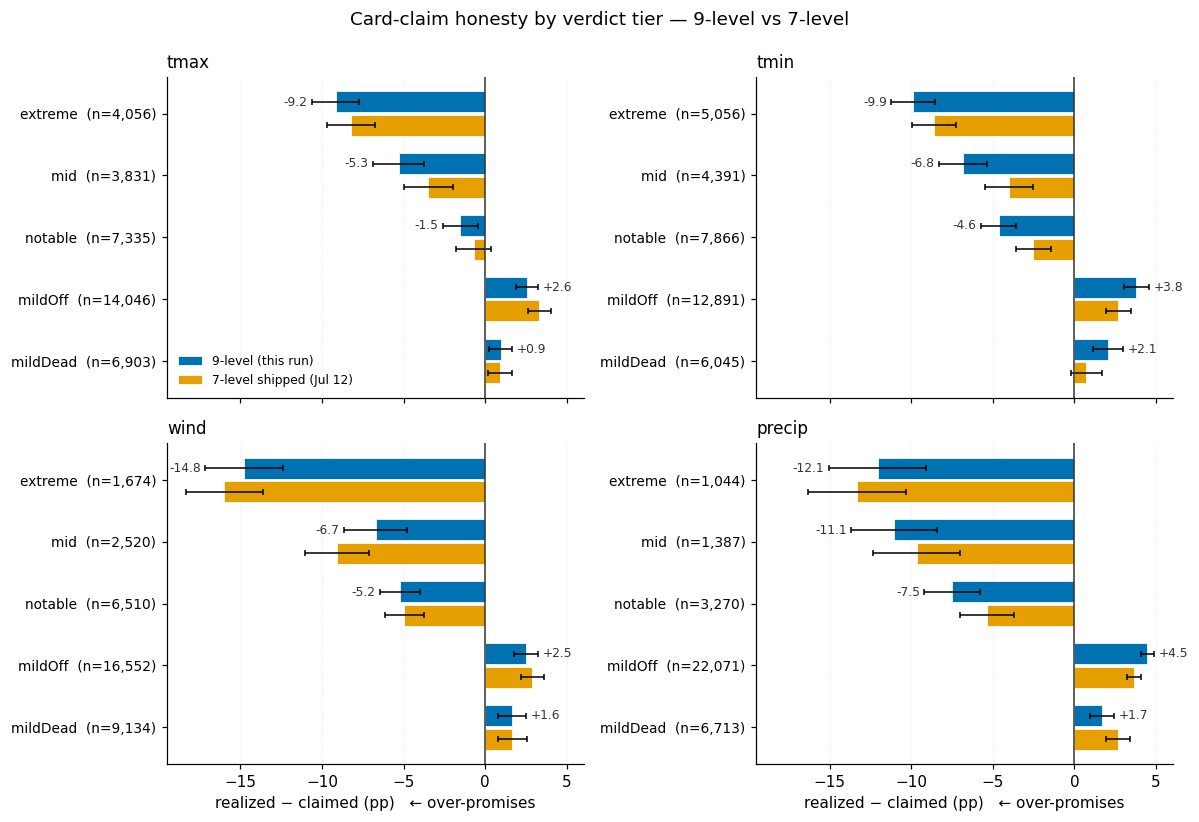

underlying numbers (gap_pp ± ci_pp; n = this run's claims):
   var     tier  n_9lvl  gap_pp_9lvl  ci_pp_9lvl  n_7lvl  gap_pp_7lvl  ci_pp_7lvl
  tmax  extreme    4056         -9.2         1.5    4028         -8.2         1.5
  tmax      mid    3831         -5.3         1.5    4022         -3.5         1.5
  tmax  notable    7335         -1.5         1.1    7307         -0.7         1.1
  tmax  mildOff   14046          2.6         0.7   13950          3.3         0.7
  tmax mildDead    6903          0.9         0.7    6875          0.9         0.7
  tmin  extreme    5056         -9.9         1.3    4898         -8.6         1.4
  tmin      mid    4391         -6.8         1.5    4335         -4.0         1.5
  tmin  notable    7866         -4.6         1.1    7742         -2.5         1.1
  tmin  mildOff   12891          3.8         0.8   13078          2.7         0.8
  tmin mildDead    6045          2.1         0.9    6136          0.7         0.9
  wind  extreme    1674        -14.8  

In [2]:
# --- figure 1: per-tier claim gap, new vs old -----------------------------------
def tier_gap_table(claims):
    "per (var, tier): mean claim, realized rate, gap in pp, Wilson half-width, n."
    records = []
    for var in VARS:
        for tier in TIER_ORDER:
            group = claims[(claims["var"] == var) & (claims.tier == tier)]
            if not len(group):
                continue
            realized = group.hit.mean()
            records.append({
                "var": var, "tier": tier, "n": len(group),
                "gap_pp": 100 * (realized - group.claimed_p.mean()),
                "ci_pp": 100 * wilson_halfwidth(realized, len(group)),
            })
    return pd.DataFrame(records)

gaps_new = tier_gap_table(claims_new)
gaps_old = tier_gap_table(claims_old)

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True)
for ax, var in zip(axes.flat, VARS):
    new_rows = gaps_new[gaps_new["var"] == var].set_index("tier").reindex(TIER_ORDER)
    old_rows = gaps_old[gaps_old["var"] == var].set_index("tier").reindex(TIER_ORDER)
    y = np.arange(len(TIER_ORDER))[::-1]                     # extreme on top
    ax.barh(y + 0.19, new_rows.gap_pp, height=0.34, color=NINE_COLOR,
            xerr=new_rows.ci_pp, error_kw=dict(lw=1, capsize=2),
            edgecolor="white", linewidth=0.5, label="9-level (this run)")
    ax.barh(y - 0.19, old_rows.gap_pp, height=0.34, color=SEVEN_COLOR,
            xerr=old_rows.ci_pp, error_kw=dict(lw=1, capsize=2),
            edgecolor="white", linewidth=0.5, label="7-level shipped (Jul 12)")
    for yi, gap, ci in zip(y + 0.19, new_rows.gap_pp, new_rows.ci_pp):
        anchor = gap + ci if gap >= 0 else gap - ci          # past the whisker
        ax.annotate(f"{gap:+.1f}", (anchor, yi), xytext=(3 if gap >= 0 else -3, 0),
                    textcoords="offset points", va="center",
                    ha="left" if gap >= 0 else "right", fontsize=8, color="#333")
    ax.axvline(0, color="#333", lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{t}  (n={int(n):,})" for t, n in
                        zip(TIER_ORDER, new_rows.n)], fontsize=9)
    ax.set_title(var, fontsize=11, loc="left")
    ax.grid(axis="y", visible=False)
axes[0, 0].legend(loc="lower left", fontsize=8, frameon=False)
for ax in axes[1]:
    ax.set_xlabel("realized − claimed (pp)   ← over-promises")
fig.suptitle("Card-claim honesty by verdict tier — 9-level vs 7-level", y=0.99)
fig.tight_layout()
plt.show()

print("underlying numbers (gap_pp ± ci_pp; n = this run's claims):")
merged = gaps_new.merge(gaps_old, on=["var", "tier"], suffixes=("_9lvl", "_7lvl"))
print(merged.round(1).to_string(index=False))

## 2 — Where inside the band the tiers go wrong: coverage error per tier × level

Upstream of the claim: is the **band itself** calibrated within each tier?
Cell value = empirical coverage at that head minus nominal, in pp
(**+ = over-covers** = band too wide there, − = under-covers). Rows with fewer
than 2,000 rows are dropped (same rule as `card_claim_reliability`), which is why
wind has no `extreme` row. Color is capped at ±15 pp — precip's saturated cells
(dry-day point mass dominates every level below its wet tail; judge precip on
q90+) print their true value.

Marginal (`ALL`) is honest everywhere; the extreme tier's *interior* over-covers
strongly on temps — that's the per-level face of the same selection effect.

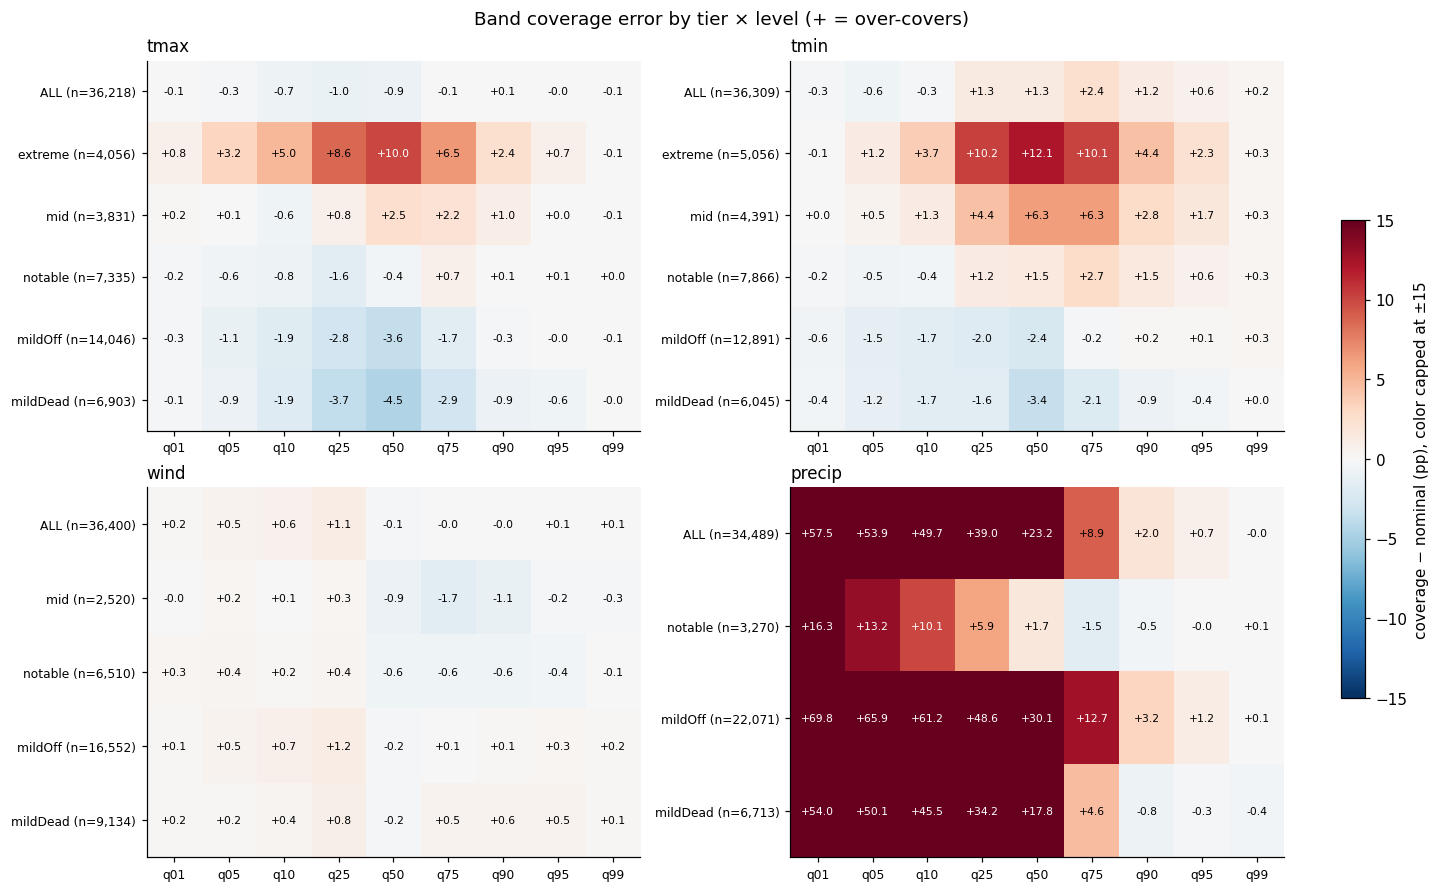

In [3]:
# --- figure 2: tier x level coverage-error heatmaps -----------------------------
TIER_COVERAGE_MIN_N = 2000
COLOR_CAP_PP = 15.0

def tier_level_errors(var):
    "rows: ALL + populated tiers; cols: 9 levels; values: coverage error in pp."
    bands = eval_bands_new[var]
    tiers = claims_new.loc[claims_new["var"] == var, ["key", "date", "tier"]]
    merged = bands.merge(tiers, on=["key", "date"], how="inner", validate="one_to_one")
    rows = []
    for tier in ["ALL"] + TIER_ORDER:
        group = merged if tier == "ALL" else merged[merged.tier == tier]
        if len(group) < TIER_COVERAGE_MIN_N:
            continue
        truth = group.truth_abs.to_numpy()
        errors = [100 * (float((truth <= group[col].to_numpy()).mean()) - p)
                  for p, col in zip(BAND_P, BAND_COLS)]
        rows.append(pd.Series(errors, index=LEVEL_LABELS, name=f"{tier} (n={len(group):,})"))
    return pd.DataFrame(rows)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), layout="constrained")
for ax, var in zip(axes.flat, VARS):
    table = tier_level_errors(var)
    shown = ax.imshow(np.clip(table.to_numpy(), -COLOR_CAP_PP, COLOR_CAP_PP),
                      cmap="RdBu_r", vmin=-COLOR_CAP_PP, vmax=COLOR_CAP_PP,
                      aspect="auto")
    ax.set_xticks(range(len(LEVEL_LABELS)), LEVEL_LABELS, fontsize=8)
    ax.set_yticks(range(len(table)), table.index, fontsize=8)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = table.iloc[i, j]
            ax.annotate(f"{value:+.1f}", (j, i), ha="center", va="center", fontsize=7,
                        color="white" if abs(value) > 0.6 * COLOR_CAP_PP else "black")
    ax.set_title(var, fontsize=11, loc="left")
    ax.grid(visible=False)
fig.colorbar(shown, ax=axes, shrink=0.6,
             label=f"coverage − nominal (pp), color capped at ±{COLOR_CAP_PP:.0f}")
fig.suptitle("Band coverage error by tier × level (+ = over-covers)")
plt.show()

## 3 — Did the two new heads pay off? Trained-head honesty, new vs old

Marginal coverage error at each of the 9 CDF anchors, this run vs the shipped
7-level tables. In the old bands q25/q75 were **probit-interpolated client-side**
(shipped 2026-07-06) — so those two positions compare *trained* against
*interpolated* directly. Precip is evaluated on wet-forecast days only
(HRES ≥ 1 mm, same protocol as `cdf_rung_coverage`); its all-days low rungs are
tie-dominated by the dry-day atom for both generations.

Note tmin: the drift above nominal across q50–q95 is the cross-month transfer
regression flagged in `cdf_rung_coverage` (these eval rows are calendar months
disjoint from the calibration months). Everything else sits on or near nominal.

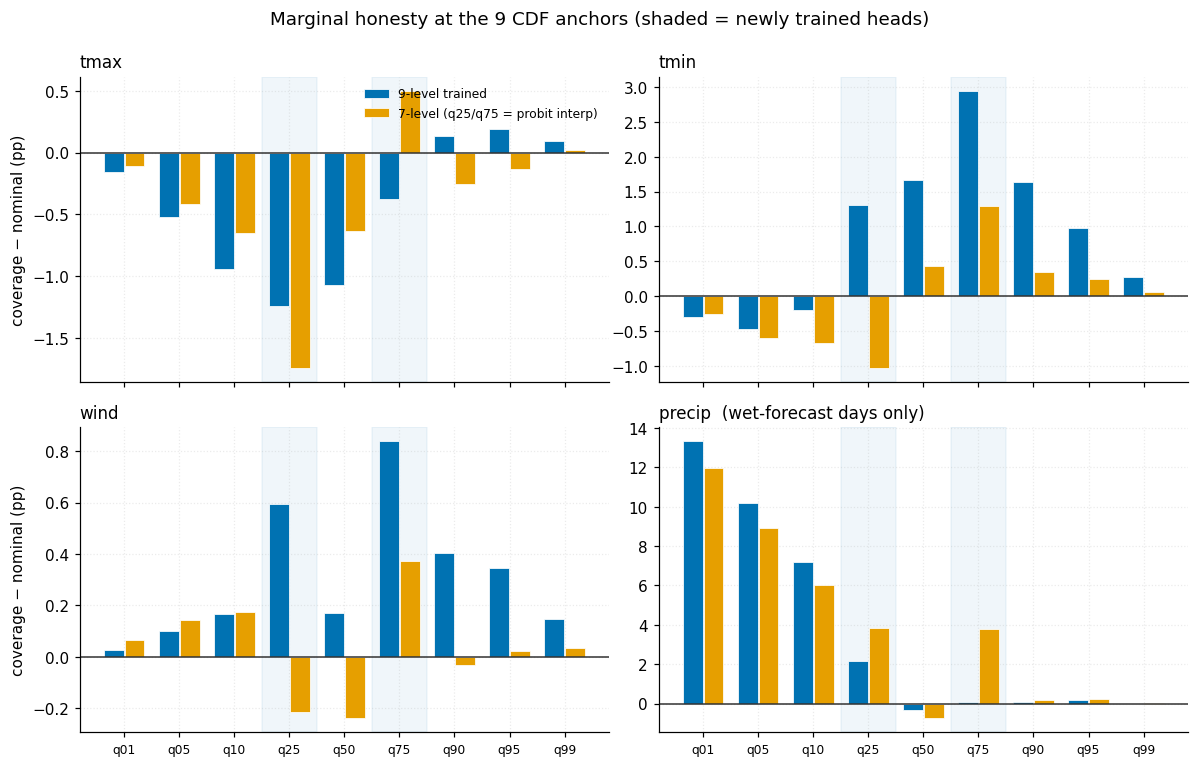

               q01    q05   q10   q25   q50   q75   q90   q95   q99
tmax   9lvl  -0.16  -0.52 -0.94 -1.24 -1.07 -0.38  0.14  0.19  0.09
       7lvl  -0.11  -0.42 -0.65 -1.75 -0.64  0.50 -0.25 -0.13  0.02
tmin   9lvl  -0.31  -0.47 -0.20  1.31  1.67  2.95  1.64  0.98  0.28
       7lvl  -0.26  -0.59 -0.67 -1.03  0.43  1.30  0.34  0.24  0.06
wind   9lvl   0.03   0.10  0.17  0.59  0.17  0.84  0.40  0.35  0.15
       7lvl   0.07   0.14  0.17 -0.21 -0.24  0.37 -0.03  0.02  0.03
precip 9lvl  13.35  10.18  7.17  2.15 -0.33  0.09  0.09  0.18 -0.04
       7lvl  11.99   8.93  6.04  3.86 -0.76  3.76  0.17  0.21  0.01


In [4]:
# --- figure 3: marginal coverage error per anchor, 9-level vs 7-level -----------
def marginal_errors(bands, var):
    rows = bands
    if var == "precip":
        rows = rows[rows.hres >= 1.0]                        # wet-forecast protocol
    truth = rows.truth_abs.to_numpy()
    return [100 * (float((truth <= rows[col].to_numpy()).mean()) - p)
            for p, col in zip(BAND_P, BAND_COLS)]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
x = np.arange(len(BAND_P))
for ax, var in zip(axes.flat, VARS):
    new_errors = marginal_errors(eval_bands_new[var], var)
    old_errors = marginal_errors(eval_bands_old[var], var)
    ax.bar(x - 0.19, new_errors, width=0.36, color=NINE_COLOR,
           edgecolor="white", linewidth=0.5, label="9-level trained")
    ax.bar(x + 0.19, old_errors, width=0.36, color=SEVEN_COLOR,
           edgecolor="white", linewidth=0.5, label="7-level (q25/q75 = probit interp)")
    ax.axhline(0, color="#333", lw=1)
    for anchor in (3, 5):                                    # the two new heads
        ax.axvspan(anchor - 0.5, anchor + 0.5, color="#0072B2", alpha=0.06, zorder=0)
    ax.set_xticks(x, LEVEL_LABELS, fontsize=8)
    title = var + ("  (wet-forecast days only)" if var == "precip" else "")
    ax.set_title(title, fontsize=11, loc="left")
for ax in axes[:, 0]:
    ax.set_ylabel("coverage − nominal (pp)")
axes[0, 0].legend(loc="upper right", fontsize=8, frameon=False)
fig.suptitle("Marginal honesty at the 9 CDF anchors (shaded = newly trained heads)", y=0.99)
fig.tight_layout()
plt.show()

comparison = pd.DataFrame(
    {(var, gen): marginal_errors(bands[var], var)
     for var in VARS for gen, bands in
     [("9lvl", eval_bands_new), ("7lvl", eval_bands_old)]},
    index=LEVEL_LABELS).T
print(comparison.round(2).to_string())

## 4 — The pinned-cycle check: 50r1 vs a season-matched control

The baked tables are pinned to `fc_version=50r1`, but the test split (and so the
conformal shifts) contains **zero** 50r1 days. The honest read: coverage on the 20
val-split 50r1 days (May 12–31 2026) minus coverage on the 11 val-split May 1–11
days that ran 49r1 — same spring, same cells, different cycle. Bars inside the
±2.5 pp band = the cycle pinning costs nothing material. Precip's low rungs are
composition-driven (dry-day share differs day-to-day); its wet tail is the read.
Source: `check_50r1_val_coverage.py`.

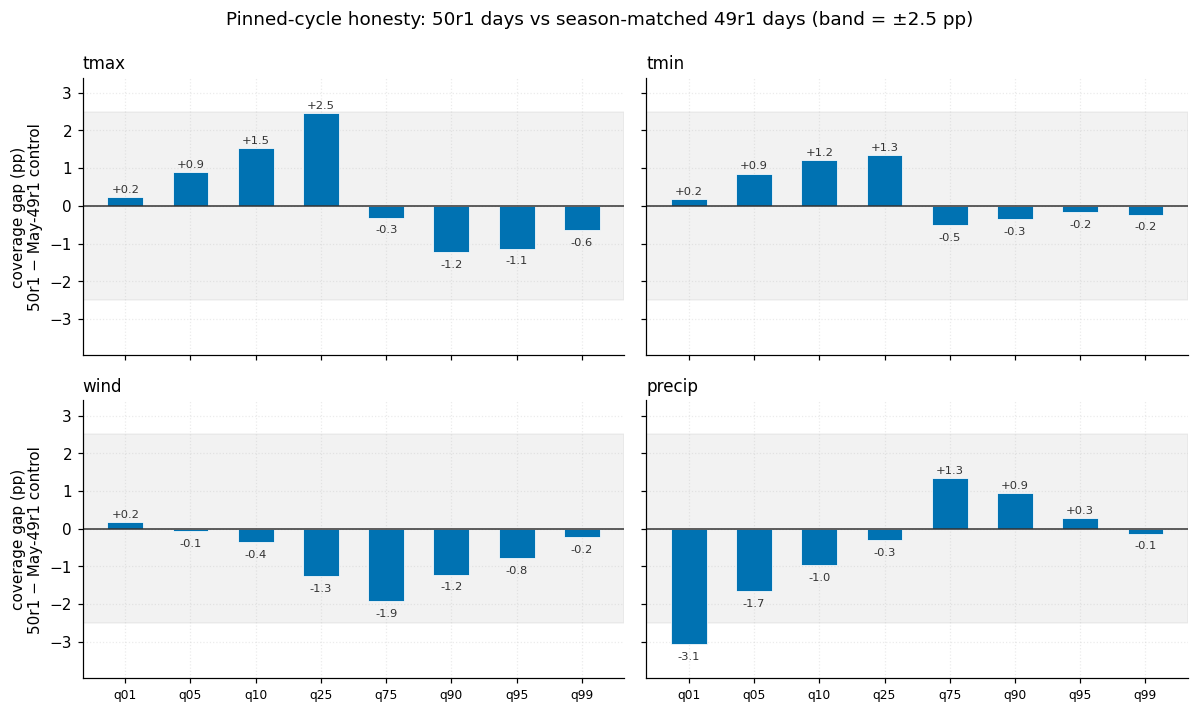

In [5]:
# --- figure 4: 50r1-vs-May-control coverage gap ---------------------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True, sharey=True)
levels_50r1 = sorted(fifty_r1.level.unique())                # 8 sided levels (no q50)
x = np.arange(len(levels_50r1))
for ax, var in zip(axes.flat, VARS):
    rows = fifty_r1[fifty_r1["var"] == var].set_index("level").reindex(levels_50r1)
    ax.axhspan(-2.5, 2.5, color="#999", alpha=0.12, zorder=0)
    ax.bar(x, rows.gap_50r1_vs_may_pp, width=0.55, color=NINE_COLOR,
           edgecolor="white", linewidth=0.5)
    for xi, gap in zip(x, rows.gap_50r1_vs_may_pp):
        ax.annotate(f"{gap:+.1f}", (xi, gap), xytext=(0, 3 if gap >= 0 else -10),
                    textcoords="offset points", ha="center", fontsize=7.5, color="#333")
    ax.axhline(0, color="#333", lw=1)
    ax.set_xticks(x, [f"q{int(l * 100):02d}" for l in levels_50r1], fontsize=8)
    ax.set_title(var, fontsize=11, loc="left")
gap_lo = fifty_r1.gap_50r1_vs_may_pp.min()
gap_hi = fifty_r1.gap_50r1_vs_may_pp.max()
axes[0, 0].set_ylim(min(gap_lo, -2.5) - 0.9, max(gap_hi, 2.5) + 0.9)  # sharey; room for labels
for ax in axes[:, 0]:
    ax.set_ylabel("coverage gap (pp)\n50r1 − May-49r1 control")
fig.suptitle("Pinned-cycle honesty: 50r1 days vs season-matched 49r1 days"
             " (band = ±2.5 pp)", y=0.99)
fig.tight_layout()
plt.show()

## Verdict

**Good**
- Marginal per-level honesty holds at 7-level parity (worst +0.44 pp, tmin q75).
- The trained q25/q75 heads beat the probit interpolation where it was weakest:
  precip's wet mid/upper rungs (+2.0…+4.8 pp errors → +0.1…+1.8 pp).
- The 50r1 pinning costs ≤2.5 pp everywhere once season-matched — not a blocker.
- Gated-cell empirical bands unchanged and healthy (see `cqr_per_level_validity`).

**Not good (known, not blockers)**
- Extreme/mid tiers still over-promise by ~9–15 pp — *unchanged* from 7-level,
  confirming Gate 2's selection-effect diagnosis. Fix = per-tier×var monotone
  p-remap in `confidence.ts`, now unblocked on `claims_reliability_{TAG}.feather`.
- tmin's shift constants transfer worse across months than the 7-level run's
  (worst rung err 2.1 → 3.8 pp; the doy-aliasing suspicion from the self-check
  flag). Marginally honest; watch after ship.

**Next**: Part 5 ship as a VERSIONED prefix: tables at `debias-v9/` + one-line `DEBIAS_PREFIX` flip in ci.ts (rollback = redeploy `dist-v7`; `VITE_DEBIAS_PREFIX` local
test); `r2_upload.py` needs the `EXTRA_TIERS` fix first. Part 4 is comment
cleanup only — `PROBIT_Q25_Q75_W` stays (it's the live 7-column fallback).